In [ ]:
!pip install torch-geometric
!pip install torch-cluster torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.1.0+cu128.html

In [ ]:
import torch
print(torch.__version__)

2.10.0+cu128


In [ ]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cu128
12.8


In [ ]:
import torch
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader

TARGET_IDX = 4

dataset = QM9(root='./data/QM9')

all_targets = dataset._data.y[:, TARGET_IDX]
TARGET_MEAN = all_targets.mean().item()
TARGET_STD  = all_targets.std().item()
dataset._data.y[:, TARGET_IDX] = (dataset._data.y[:, TARGET_IDX] - TARGET_MEAN) / TARGET_STD

torch.manual_seed(42)
train_dataset = dataset[:110000]
val_dataset   = dataset[110000:120000]
test_dataset  = dataset[120000:130000]

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"done. training：{len(train_dataset)}，validating：{len(val_dataset)}，testing：{len(test_dataset)}")

done. training：110000，validating：10000，testing：10000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/24788_project/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Drive 挂载成功，保存路径：{SAVE_DIR}")

Mounted at /content/drive
Drive 挂载成功，保存路径：/content/drive/MyDrive/24788_project/


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device：{DEVICE}")

class SchNetModel(nn.Module):
    def __init__(self, hidden_channels=128, num_interactions=6):
        super().__init__()
        self.embedding = nn.Embedding(100, hidden_channels)
        self.dist_embedding = nn.Sequential(
            nn.Linear(1, hidden_channels), nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.interactions = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels), nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
            ) for _ in range(num_interactions)
        ])
        self.output = nn.Sequential(
            nn.Linear(hidden_channels, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, data):
        z = data.x[:, 0].long()
        pos, edge_index, batch = data.pos, data.edge_index, data.batch
        h = self.embedding(z)
        row, col = edge_index
        dist = (pos[row] - pos[col]).norm(dim=-1, keepdim=True)
        edge_feat = self.dist_embedding(dist)
        for interaction in self.interactions:
            agg = torch.zeros_like(h)
            msg = h[col] * edge_feat
            agg.scatter_add_(0, row.unsqueeze(-1).expand_as(msg), msg)
            h = h + interaction(agg)
        h = global_mean_pool(h, batch)
        return self.output(h).squeeze(-1)


class DimeNetModel(nn.Module):
    def __init__(self, hidden_channels=128, num_interactions=6):
        super().__init__()
        self.embedding = nn.Embedding(100, hidden_channels)
        self.dist_embedding = nn.Sequential(
            nn.Linear(1, hidden_channels), nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.angle_embedding = nn.Sequential(
            nn.Linear(1, hidden_channels), nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )
        self.interactions = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_channels, hidden_channels), nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
            ) for _ in range(num_interactions)
        ])
        self.output = nn.Sequential(
            nn.Linear(hidden_channels, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, data):
        z = data.x[:, 0].long()
        pos, edge_index, batch = data.pos, data.edge_index, data.batch
        h = self.embedding(z)
        row, col = edge_index

        diff = pos[row] - pos[col]
        dist = diff.norm(dim=-1, keepdim=True)
        edge_feat = self.dist_embedding(dist)

        diff_norm = diff / dist.clamp(min=1e-8)  # [num_edges, 3]

        avg_dir = torch.zeros(h.shape[0], 3, device=h.device)
        avg_dir.scatter_add_(0, row.unsqueeze(-1).expand(-1, 3), diff_norm)
        count = torch.zeros(h.shape[0], 1, device=h.device)
        count.scatter_add_(0, row.unsqueeze(-1), torch.ones(row.shape[0], 1, device=h.device))
        avg_dir = avg_dir / count.clamp(min=1e-8)  # [num_nodes, 3]

        cos_angle = (diff_norm * avg_dir[row]).sum(dim=-1, keepdim=True).clamp(-1, 1)
        angle_feat_edge = self.angle_embedding(cos_angle)  # [num_edges, hidden]

        angle_feat = torch.zeros_like(h)
        angle_feat.scatter_add_(0, row.unsqueeze(-1).expand_as(angle_feat_edge), angle_feat_edge)

        for interaction in self.interactions:
            agg = torch.zeros_like(h)
            msg = h[col] * edge_feat
            agg.scatter_add_(0, row.unsqueeze(-1).expand_as(msg), msg)
            h = h + interaction(agg + angle_feat)

        h = global_mean_pool(h, batch)
        return self.output(h).squeeze(-1)

# --- training ---
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        pred   = model(batch)
        target = batch.y[:, TARGET_IDX]
        loss   = nn.functional.mse_loss(pred, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_mae = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        pred   = model(batch) * TARGET_STD + TARGET_MEAN
        target = batch.y[:, TARGET_IDX] * TARGET_STD + TARGET_MEAN
        total_mae += (pred - target).abs().sum().item()
    return total_mae / len(loader.dataset)

def train_model(model, model_name, num_epochs=100):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    history = {'train_loss': [], 'val_mae': []}
    best_val_mae = float('inf')
    print(f"\n{'='*50}")
    print(f"train {model_name}  |  parameters：{sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*50}")
    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_mae    = evaluate(model, val_loader)
        scheduler.step(val_mae)
        history['train_loss'].append(train_loss)
        history['val_mae'].append(val_mae)
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), f'best_{model_name}.pt')
            torch.save(model.state_dict(), f'{SAVE_DIR}best_{model_name}.pt')
        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
                  f"Val MAE: {val_mae*1000:.1f} meV | Best: {best_val_mae*1000:.1f} meV")
    return history, best_val_mae

histories, best_val_mae_dict, param_counts = {}, {}, {}
print("definition done")

device：cuda
definition done


In [ ]:
schnet_model = SchNetModel()
param_counts['SchNet'] = sum(p.numel() for p in schnet_model.parameters())
histories['SchNet'], best_val_mae_dict['SchNet'] = train_model(schnet_model, 'SchNet', num_epochs=100)


train SchNet  |  parameters：236,033
Epoch  10 | Loss: 0.0357 | Val MAE: 167.3 meV | Best: 167.3 meV
Epoch  20 | Loss: 0.0250 | Val MAE: 147.5 meV | Best: 139.9 meV
Epoch  30 | Loss: 0.0182 | Val MAE: 143.1 meV | Best: 126.1 meV
Epoch  40 | Loss: 0.0156 | Val MAE: 133.0 meV | Best: 125.0 meV
Epoch  50 | Loss: 0.0136 | Val MAE: 115.1 meV | Best: 113.3 meV
Epoch  60 | Loss: 0.0133 | Val MAE: 114.5 meV | Best: 109.5 meV
Epoch  70 | Loss: 0.0084 | Val MAE: 106.4 meV | Best: 106.4 meV
Epoch  80 | Loss: 0.0072 | Val MAE: 103.2 meV | Best: 101.9 meV
Epoch  90 | Loss: 0.0064 | Val MAE: 100.1 meV | Best: 99.4 meV
Epoch 100 | Loss: 0.0062 | Val MAE: 100.1 meV | Best: 97.5 meV


In [ ]:
dimenet_model = DimeNetModel()
param_counts['DimeNet'] = sum(p.numel() for p in dimenet_model.parameters())
histories['DimeNet'], best_val_mae_dict['DimeNet'] = train_model(dimenet_model, 'DimeNet', num_epochs=100)


train DimeNet  |  parameters：252,801
Epoch  10 | Loss: 0.0332 | Val MAE: 149.7 meV | Best: 149.7 meV
Epoch  20 | Loss: 0.0204 | Val MAE: 132.3 meV | Best: 131.5 meV
Epoch  30 | Loss: 0.0167 | Val MAE: 123.4 meV | Best: 117.2 meV
Epoch  40 | Loss: 0.0126 | Val MAE: 114.7 meV | Best: 108.4 meV
Epoch  50 | Loss: 0.0109 | Val MAE: 105.0 meV | Best: 104.7 meV
Epoch  60 | Loss: 0.0095 | Val MAE: 101.2 meV | Best: 97.9 meV
Epoch  70 | Loss: 0.0087 | Val MAE: 100.3 meV | Best: 97.9 meV
Epoch  80 | Loss: 0.0055 | Val MAE: 92.8 meV | Best: 88.6 meV
Epoch  90 | Loss: 0.0039 | Val MAE: 87.7 meV | Best: 85.0 meV
Epoch 100 | Loss: 0.0036 | Val MAE: 86.0 meV | Best: 84.4 meV


## rerun DimNet from 100 epoch

In [ ]:
histories = {'DimeNet': {'train_loss': [], 'val_mae': []}}
best_val_mae_dict = {}
param_counts = {}
dimenet_model = DimeNetModel()
param_counts['DimeNet'] = sum(p.numel() for p in dimenet_model.parameters())

dimenet_model.load_state_dict(torch.load(f'{SAVE_DIR}best_DimeNet.pt'))

histories_extra, best_val_mae_dict['DimeNet'] = train_model(
    dimenet_model, 'DimeNet', num_epochs=100
)

histories['DimeNet']['train_loss'] += histories_extra['train_loss']
histories['DimeNet']['val_mae']    += histories_extra['val_mae']


train DimeNet  |  parameters：252,801
Epoch  10 | Loss: 0.0076 | Val MAE: 94.7 meV | Best: 94.3 meV
Epoch  20 | Loss: 0.0072 | Val MAE: 107.5 meV | Best: 93.1 meV
Epoch  30 | Loss: 0.0075 | Val MAE: 91.8 meV | Best: 91.7 meV
Epoch  40 | Loss: 0.0040 | Val MAE: 85.8 meV | Best: 83.8 meV
Epoch  50 | Loss: 0.0037 | Val MAE: 89.5 meV | Best: 83.7 meV
Epoch  60 | Loss: 0.0026 | Val MAE: 83.5 meV | Best: 81.3 meV
Epoch  70 | Loss: 0.0024 | Val MAE: 85.5 meV | Best: 81.2 meV
Epoch  80 | Loss: 0.0022 | Val MAE: 81.7 meV | Best: 81.2 meV
Epoch  90 | Loss: 0.0021 | Val MAE: 87.9 meV | Best: 80.4 meV
Epoch 100 | Loss: 0.0017 | Val MAE: 82.0 meV | Best: 80.0 meV



Model         Val MAE (meV)  Test MAE (meV)   # Params
SchNet                 97.5           158.3    236,033
DimeNet                84.4           124.9    252,801


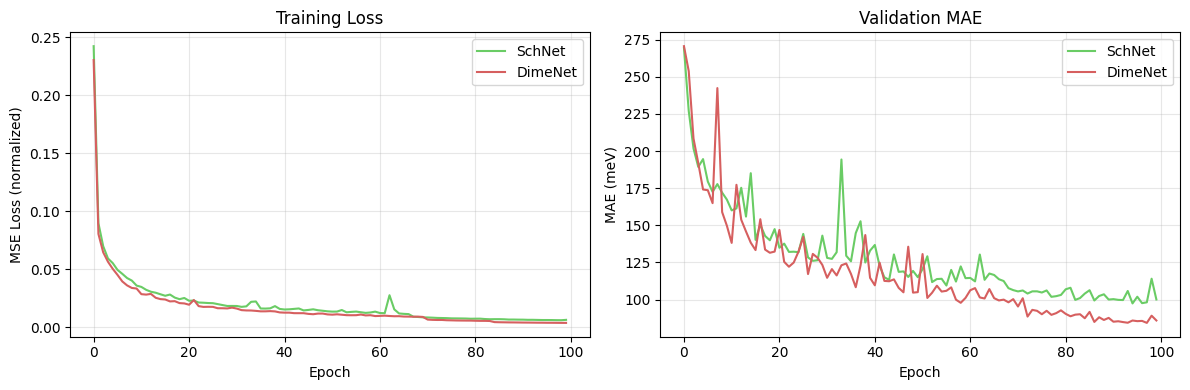

saved as training_curves.pdf


In [ ]:
test_results = {}
for model, name in [(schnet_model, 'SchNet'), (dimenet_model, 'DimeNet')]:
    model.load_state_dict(torch.load(f'{SAVE_DIR}best_{name}.pt'))
    test_results[name] = evaluate(model, test_loader)

print("\n" + "="*55)
print(f"{'Model':<12} {'Val MAE (meV)':>14} {'Test MAE (meV)':>15} {'# Params':>10}")
print("="*55)
for name in ['SchNet', 'DimeNet']:
    print(f"{name:<12} {best_val_mae_dict[name]*1000:>14.1f} "
          f"{test_results[name]*1000:>15.1f} {param_counts[name]:>10,}")
print("="*55)

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
colors = {'SchNet': '#6ACC65', 'DimeNet': '#D65F5F'}
for name in ['SchNet', 'DimeNet']:
    ax1.plot(histories[name]['train_loss'], label=name, color=colors[name], lw=1.5)
    ax2.plot([m*1000 for m in histories[name]['val_mae']], label=name, color=colors[name], lw=1.5)
for ax, title, ylabel in [
    (ax1, 'Training Loss', 'MSE Loss (normalized)'),
    (ax2, 'Validation MAE', 'MAE (meV)')]:
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}training_curves.pdf', bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}training_curves.png', bbox_inches='tight')
plt.show()
print(f"saved to {SAVE_DIR}")

In [ ]:
print(histories.keys())

dict_keys(['DimeNet'])


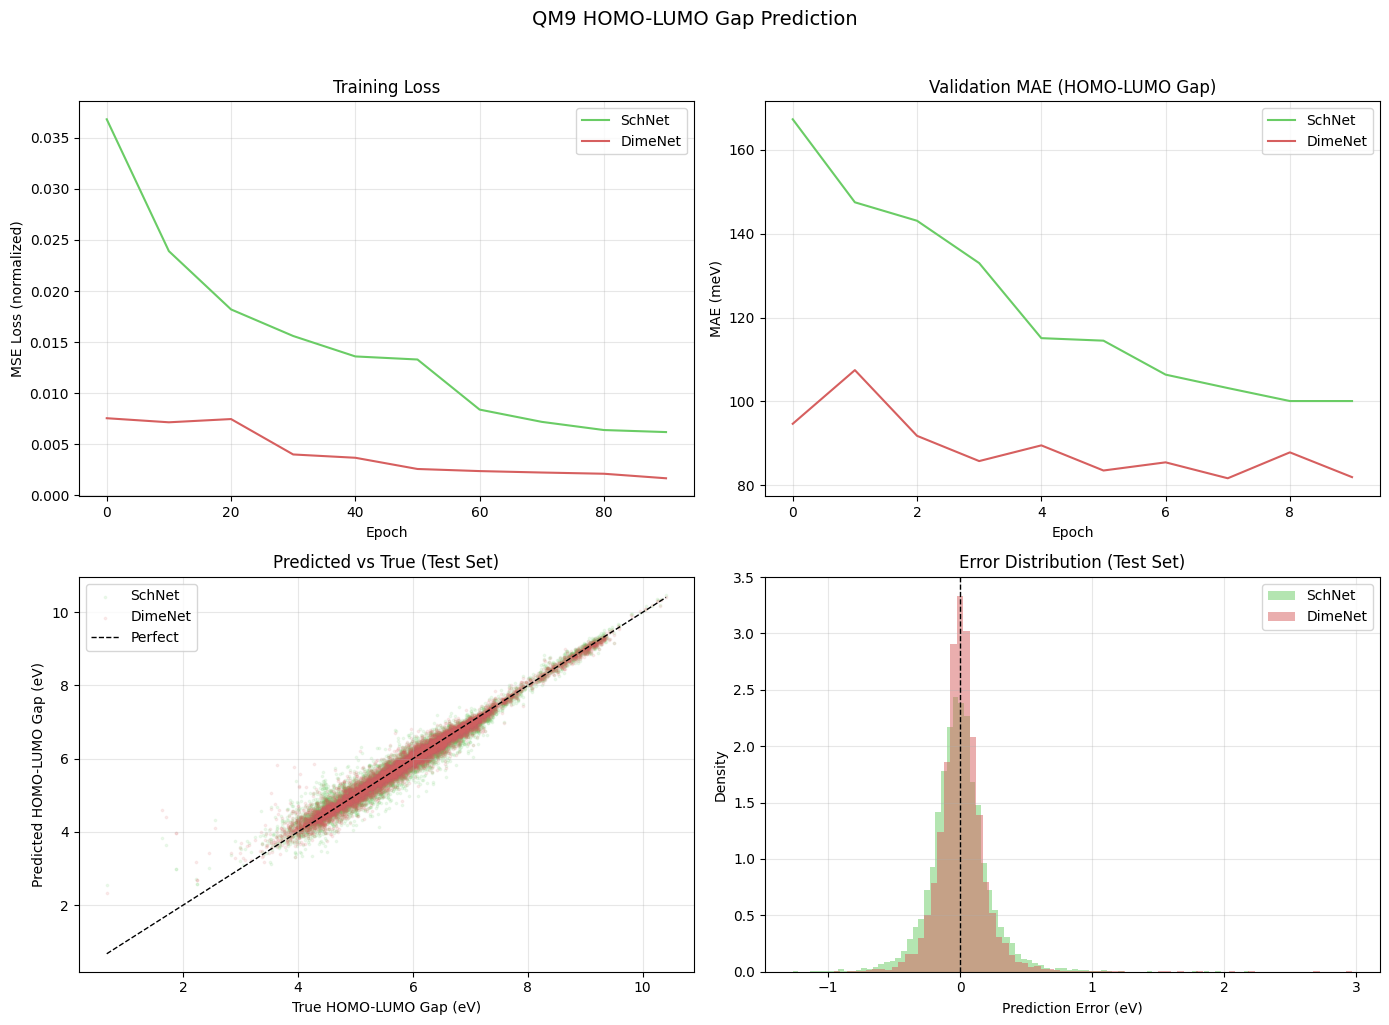

saved to /content/drive/MyDrive/24788_project/

Model         Val MAE (meV)  Test MAE (meV)   # Params
SchNet                 97.5           158.3    236,033
DimeNet                80.0           120.3    252,801


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ---- restore ----
schnet_model = SchNetModel()
schnet_model.load_state_dict(torch.load(f'{SAVE_DIR}best_SchNet.pt'))
schnet_model = schnet_model.to(DEVICE)

# SchNet
histories['SchNet'] = {
    'train_loss': [0.0368, 0.0239, 0.0182, 0.0156, 0.0136, 0.0133, 0.0084, 0.0072, 0.0064, 0.0062],
    'val_mae':    [0.1673, 0.1475, 0.1431, 0.1330, 0.1151, 0.1145, 0.1064, 0.1032, 0.1001, 0.1001]
}

best_val_mae_dict['SchNet'] = 0.0975
param_counts['SchNet'] = 236033

# ---- fig ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'SchNet': '#6ACC65', 'DimeNet': '#D65F5F'}
# 在画图代码最前面加这两行
histories['DimeNet']['train_loss'] = histories['DimeNet']['train_loss'][9::10]
histories['DimeNet']['val_mae']    = histories['DimeNet']['val_mae'][9::10]

# fig1: Training Loss
ax = axes[0, 0]
for name in ['SchNet', 'DimeNet']:
    y = histories[name]['train_loss']
    x = [i * (100 / len(y)) for i in range(len(y))]
    ax.plot(x, y, label=name, color=colors[name], lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (normalized)')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# fig2: Validation MAE
ax = axes[0, 1]
for name in ['SchNet', 'DimeNet']:
    y = histories[name]['val_mae']
    x = [i * (100 / len(y)) for i in range(len(y))]
    ax.plot([m*1000 for m in y], label=name, color=colors[name], lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (meV)')
ax.set_title('Validation MAE (HOMO-LUMO Gap)')
ax.legend()
ax.grid(True, alpha=0.3)

# fig3: Predicted vs True
ax = axes[1, 0]
for name, model in [('SchNet', schnet_model), ('DimeNet', dimenet_model)]:
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            pred = model(batch) * TARGET_STD + TARGET_MEAN
            tgt  = batch.y[:, TARGET_IDX] * TARGET_STD + TARGET_MEAN
            preds.extend(pred.cpu().numpy())
            targets.extend(tgt.cpu().numpy())
    ax.scatter(targets, preds, alpha=0.1, s=3, color=colors[name], label=name)
lim = [min(targets), max(targets)]
ax.plot(lim, lim, 'k--', lw=1, label='Perfect')
ax.set_xlabel('True HOMO-LUMO Gap (eV)')
ax.set_ylabel('Predicted HOMO-LUMO Gap (eV)')
ax.set_title('Predicted vs True (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)

# fig4: Error Distribution
ax = axes[1, 1]
for name, model in [('SchNet', schnet_model), ('DimeNet', dimenet_model)]:
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            pred = model(batch) * TARGET_STD + TARGET_MEAN
            tgt  = batch.y[:, TARGET_IDX] * TARGET_STD + TARGET_MEAN
            errors.extend((pred - tgt).cpu().numpy())
    ax.hist(errors, bins=80, alpha=0.5, color=colors[name], label=name, density=True)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_xlabel('Prediction Error (eV)')
ax.set_ylabel('Density')
ax.set_title('Error Distribution (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('QM9 HOMO-LUMO Gap Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}all_figures.pdf', bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}all_figures.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"saved to {SAVE_DIR}")

# ---- print ----
test_results = {}
for model, name in [(schnet_model, 'SchNet'), (dimenet_model, 'DimeNet')]:
    model.load_state_dict(torch.load(f'{SAVE_DIR}best_{name}.pt'))
    test_results[name] = evaluate(model, test_loader)

print("\n" + "="*55)
print(f"{'Model':<12} {'Val MAE (meV)':>14} {'Test MAE (meV)':>15} {'# Params':>10}")
print("="*55)
for name in ['SchNet', 'DimeNet']:
    print(f"{name:<12} {best_val_mae_dict[name]*1000:>14.1f} "
          f"{test_results[name]*1000:>15.1f} {param_counts[name]:>10,}")
print("="*55)

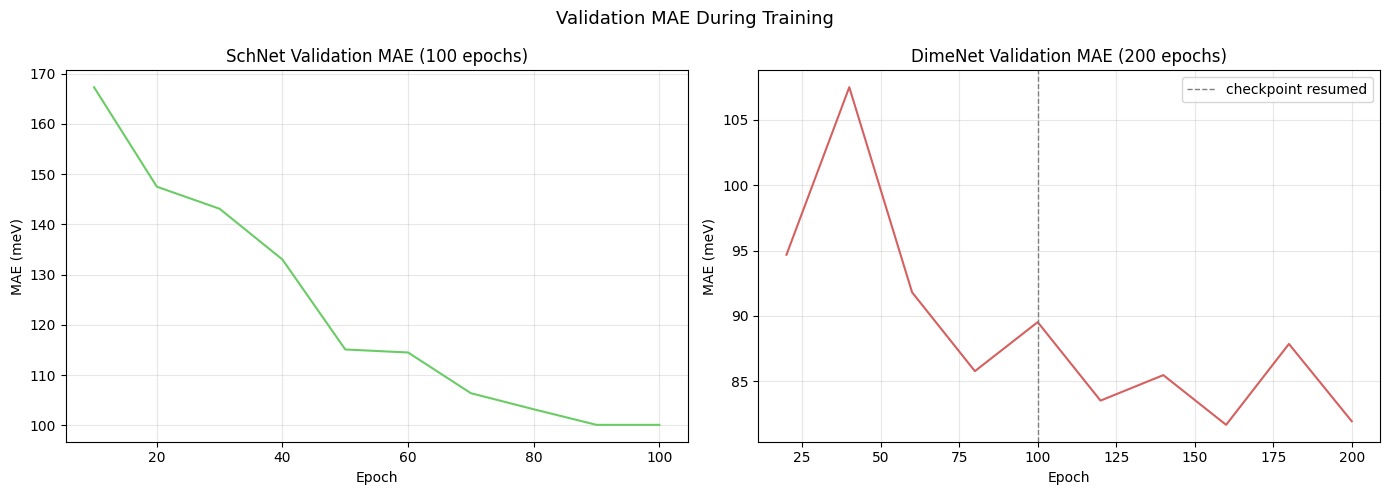

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- SchNet：10represent100 epochs ----
ax = axes[0]
x_schnet = list(range(10, 101, 10))  # [10,20,...,100]
ax.plot(x_schnet, [m*1000 for m in histories['SchNet']['val_mae']],
        color='#6ACC65', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (meV)')
ax.set_title('SchNet Validation MAE (100 epochs)')
ax.grid(True, alpha=0.3)

# ---- DimeNet：10个represent200 epochs ----
ax = axes[1]
x_dimenet = list(range(20, 201, 20))  # [20,40,...,200]
ax.plot(x_dimenet, [m*1000 for m in histories['DimeNet']['val_mae']],
        color='#D65F5F', lw=1.5)
ax.axvline(x=100, color='gray', lw=1, linestyle='--', label='checkpoint resumed')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (meV)')
ax.set_title('DimeNet Validation MAE (200 epochs)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Validation MAE During Training', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}mae_curves.pdf', bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}mae_curves.png', bbox_inches='tight', dpi=150)
plt.show()